### Imports

In [2]:
import json
import warnings
from pathlib import Path

import torch
import torch.nn as nn

from src.datasets.audio_dataset import AudioDataset
from src.engine import benchmark_snn, validate_snn, train_one_epoch_snn, get_split_dataloaders
from src.models.snn_2d_direct_classifier import SNN2DDirectClassifier
from src.preprocessing import get_snn_pipeline
from src.utils import plot_training_history, run_sweep_pareto

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [3]:
MODEL_NAME = SNN2DDirectClassifier.NAME

INPUT_DIR = Path('../../data/audioMNIST')
HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{MODEL_NAME}.json')
MODEL_PATH = Path(f'../../models/{MODEL_NAME}.pth')

NUM_EPOCHS = 20

### Device

In [4]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [5]:
def objective(trial) -> tuple[float, int]:
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    beta = trial.suggest_float('beta_init', 0.5, 0.99)
    slope = trial.suggest_int('slope', 10, 50)
    timesteps = trial.suggest_categorical('timesteps', [5, 10, 15])

    dataset = AudioDataset(INPUT_DIR, get_snn_pipeline())
    train_dataloader, val_dataloader, _ = get_split_dataloaders(dataset)

    model = SNN2DDirectClassifier(beta_init=beta, slope=slope, timesteps=timesteps).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    val_acc = 0.0
    for epoch in range(3):
        train_one_epoch_snn(device, model, criterion, optimiser, train_dataloader, leave=False)
        val_loss, val_acc = validate_snn(device, model, criterion, val_dataloader, leave=False)

    return val_acc, timesteps

run_sweep_pareto(objective, HYPERPARAMETERS_PATH, 20)


[I 2026-03-08 20:24:09,534] A new study created in memory with name: no-name-d3223704-a64a-48db-9b54-363f63b8a947


Running hyperparameter sweep (Pareto front)...


[I 2026-03-08 20:26:06,915] Trial 0 finished with values: [98.03333333333333, 10.0] and parameters: {'lr': 0.0032147668157968185, 'beta_init': 0.699207826769044, 'slope': 28, 'timesteps': 10}.
[I 2026-03-08 20:27:45,416] Trial 1 finished with values: [74.43333333333334, 5.0] and parameters: {'lr': 0.004377018844536634, 'beta_init': 0.7942001454429213, 'slope': 49, 'timesteps': 5}.
[I 2026-03-08 20:29:25,339] Trial 2 finished with values: [88.46666666666667, 5.0] and parameters: {'lr': 0.00024124339827848008, 'beta_init': 0.9118899485408963, 'slope': 44, 'timesteps': 5}.
[I 2026-03-08 20:31:01,740] Trial 3 finished with values: [91.36666666666666, 5.0] and parameters: {'lr': 0.00780945261363538, 'beta_init': 0.540946266026266, 'slope': 50, 'timesteps': 5}.
[I 2026-03-08 20:34:14,579] Trial 4 finished with values: [96.2, 15.0] and parameters: {'lr': 0.0012542320022043882, 'beta_init': 0.5662005941435544, 'slope': 48, 'timesteps': 15}.
[I 2026-03-08 20:36:31,087] Trial 5 finished with val

[REMEMBER TO MANUALLY SELECT BEST SET OF HYPERPARAMETERS]
Hyperparameter sweep completed.


### Training

Features shape: torch.Size([64, 1, 64, 27])
Labels shape: torch.Size([64])

Hyperparameters used: {'lr': 0.004147918074122713, 'beta_init': 0.9820996644529979, 'slope': 11, 'timesteps': 5}

Training snn_2d_direct...
[Epoch 1/20]


Validating: 100%|██████████| 47/47 [00:04<00:00, 11.12batches/s]


Train Loss: 1.31 | Train Accuracy: 50.10% | Val Loss: 0.80 | Val Accuracy: 74.93%

[Epoch 2/20]


Validating: 100%|██████████| 47/47 [00:01<00:00, 27.54batches/s]


Train Loss: 0.25 | Train Accuracy: 94.56% | Val Loss: 0.30 | Val Accuracy: 96.40%

[Epoch 3/20]


...

Train Loss: 0.09 | Train Accuracy: 99.41% | Val Loss: 0.17 | Val Accuracy: 98.50%

[Epoch 20/20]


Validating: 100%|██████████| 47/47 [00:01<00:00, 23.64batches/s]


Train Loss: 0.08 | Train Accuracy: 99.69% | Val Loss: 0.15 | Val Accuracy: 99.00%

Best model had an accuracy of 99.20%.
Running final test...

Benchmarking: 100%|██████████| 47/47 [00:05<00:00,  9.07batches/s]


Test accuracy: 99.03% | Total ACs: 959040.2953333333


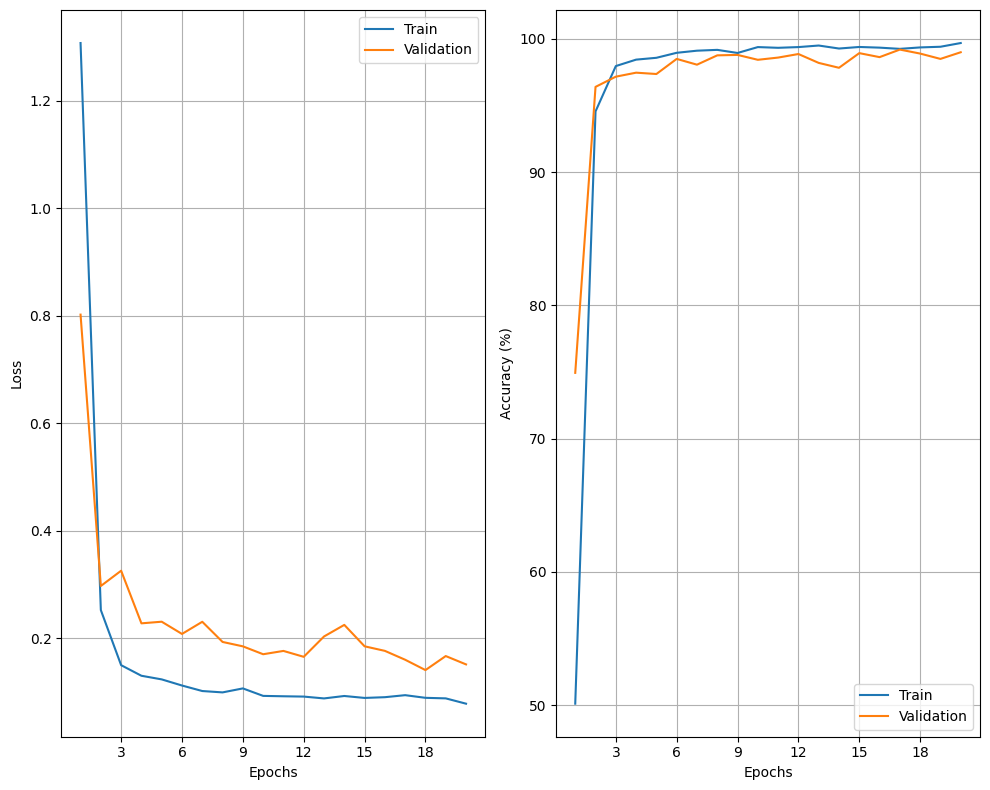

In [6]:
# TODO: Keep track of both MACs and ACs
if __name__ == '__main__':
    dataset = AudioDataset(INPUT_DIR, get_snn_pipeline())
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Load hyperparameters
    # NOTE: Make sure to change which set of parameters to use, by default take the highest accuracy
    hyperparameters = json.load(open(HYPERPARAMETERS_PATH, 'r'))[0]['params']
    print(f'Hyperparameters used: {hyperparameters}')
    print()

    # Train the model
    model = SNN2DDirectClassifier(beta_init=hyperparameters['slope'], slope=hyperparameters['slope'], timesteps=hyperparameters['timesteps']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters['lr'])
    criterion = nn.CrossEntropyLoss()

    print(f'Training {model.NAME}...')
    best_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(NUM_EPOCHS):
        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss, train_acc = train_one_epoch_snn(device, model, criterion, optimizer, train_dataloader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = validate_snn(device, model, criterion, val_dataloader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_acc:.2f}%')
        print()
    print(f'Best model had an accuracy of {best_acc:.2f}%.')
    print(f'Running final test...', end='')
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint, strict=True)
    model.to(device)

    test_accuracy, acs = benchmark_snn(device, model, test_dataloader)
    print(f'Test accuracy: {test_accuracy:.2f}% | Total ACs: {acs}')

    plot_training_history(train_losses, train_accs, val_losses, val_accs)